# Step 4: The Ising Model with External Field — First-Order vs Continuous Transitions

In notebooks 01–03 the Hamiltonian has always had a $\mathbb{Z}_2$ symmetry: flipping all spins costs nothing. Adding an external field $h$ breaks that symmetry explicitly and produces a much richer phase diagram — including a qualitatively different kind of transition, the **first-order phase transition**, where the order parameter jumps discontinuously.

**What you will do:**
- Modify the Metropolis algorithm to include the field term
- Map out $m(h)$ at fixed temperatures and observe the discontinuous jump for $T < T_c$
- Measure **hysteresis** by sweeping $h$ forward and backward
- Watch the jump shrink and vanish as $T \to T_c$ from below
- Visualise the **Landau free energy** landscape underlying all of this

**Prerequisites:** Notebooks 01 and 02.

## 4.1  The Hamiltonian with External Field

We add a coupling to an external magnetic field $h$:

$$H = -J \sum_{\langle i,j \rangle} s_i s_j - h \sum_i s_i$$

The field term $-h s_i$ favours spin-up sites when $h > 0$ and spin-down sites when $h < 0$. It breaks the $\mathbb{Z}_2$ symmetry: configurations with all spins up and all spins down are no longer equivalent.

The energy change when flipping spin $s_i$ now has two contributions:

$$\Delta E = 2J\, s_i \sum_{n \in \mathrm{nn}(i)} s_n + 2h\, s_i$$

The first term is the neighbour interaction from notebook 01; the second comes from the fact that flipping $s_i \to -s_i$ changes the field energy from $-h s_i$ to $+h s_i$, a change of $2h s_i$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

J  = 1.0
TC = 2.0 / np.log(1 + np.sqrt(2))   # Onsager exact value ≈ 2.2692

def lattice_init(L):
    return 2 * np.random.randint(0, 2, size=(L, L)) - 1

def delta_energy(lattice, L, i, j, J, h):
    """Energy change for flipping site (i, j), including the field term."""
    spin   = lattice[i, j]
    nn_sum = (lattice[i, (j + 1) % L] + lattice[i, (j - 1) % L] +
              lattice[(i - 1) % L, j] + lattice[(i + 1) % L, j])
    return 2 * J * spin * nn_sum + 2 * h * spin

def metropolis(lattice, L, beta, J, h, steps):
    """Metropolis sweep with external field h."""
    rand_i = np.random.randint(0, L, steps)
    rand_j = np.random.randint(0, L, steps)
    rand_u = np.random.random(steps)
    for k in range(steps):
        dE = delta_energy(lattice, L, rand_i[k], rand_j[k], J, h)
        if dE < 0 or np.exp(-beta * dE) > rand_u[k]:
            lattice[rand_i[k], rand_j[k]] *= -1

print(f"T_c = {TC:.6f}")

T_c = 2.269185


## 4.2  The Phase Diagram

The $(T, h)$ phase diagram has the following structure:

- **Right of $T_c$, or away from $h = 0$:** paramagnetic phase — $m$ varies smoothly, no transition.
- **Along $h = 0$ for $T < T_c$:** a **first-order transition line**. Crossing it (varying $h$ through zero at fixed $T < T_c$) causes $m$ to jump discontinuously from $+m_0(T)$ to $-m_0(T)$.
- **At $(T_c,\, 0)$:** the **critical endpoint** where the first-order line terminates. Here the jump vanishes continuously — this is the second-order transition of notebooks 01 and 02.

The same structure — a line of first-order transitions ending at a critical point — appears in the liquid-gas phase diagram and in many quantum phase diagrams.

Below we visualise this by sweeping $T$ at several fixed field values and plotting the resulting magnetization curves.

h = 0.0 ... done
h = 0.1 ... done
h = 0.3 ... done
h = 0.6 ... done


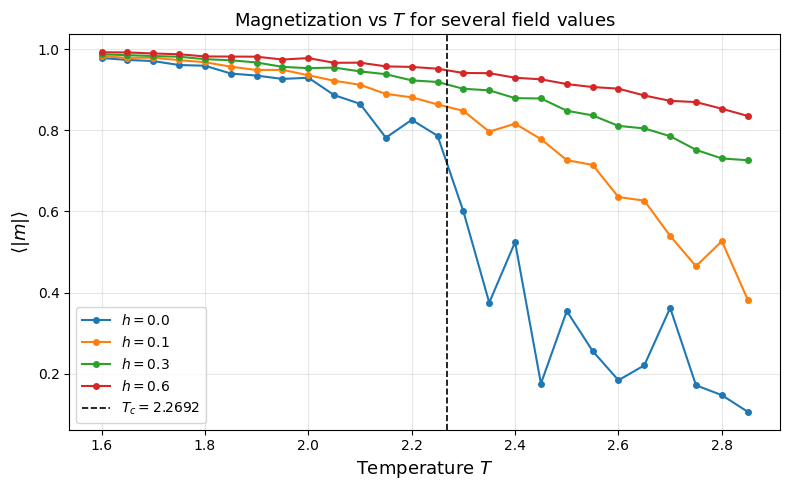

In [2]:
L           = 24
T_VALUES    = np.arange(1.6, 2.9, 0.05)
H_FIXED     = [0.0, 0.1, 0.3, 0.6]
EQUIL_STEPS = 80_000
N_SAMPLES   = 150
SAMPLE_INT  = 500

results_T = {}   # results_T[h] = array of <|m|> vs T

for h in H_FIXED:
    print(f"h = {h:.1f} ...", end=' ', flush=True)
    mags = []
    lattice = lattice_init(L)
    for T in T_VALUES:
        beta = 1.0 / T
        metropolis(lattice, L, beta, J, h, EQUIL_STEPS)
        m_samples = []
        for _ in range(N_SAMPLES):
            metropolis(lattice, L, beta, J, h, SAMPLE_INT)
            m_samples.append(abs(np.mean(lattice)))
        mags.append(np.mean(m_samples))
    results_T[h] = np.array(mags)
    print("done")

fig, ax = plt.subplots(figsize=(8, 5))
for h in H_FIXED:
    ax.plot(T_VALUES, results_T[h], 'o-', ms=4, lw=1.5, label=f"$h = {h}$")
ax.axvline(TC, color='k', ls='--', lw=1.2, label=f"$T_c = {TC:.4f}$")
ax.set_xlabel("Temperature $T$", fontsize=13)
ax.set_ylabel(r"$\langle |m| \rangle$", fontsize=13)
ax.set_title("Magnetization vs $T$ for several field values", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3  First-Order Jump: $m$ vs $h$ at Fixed Temperature

The clearest signature of a first-order transition is a **discontinuous jump** in the order parameter. We see this by fixing $T < T_c$ and sweeping $h$ through zero.

At each $h$, we fully re-equilibrate from the previous state and measure the equilibrium magnetization. For $T < T_c$ the resulting $m(h)$ curve is steep near $h = 0$ — in the thermodynamic limit it would be a vertical discontinuity. For $T > T_c$ it is smooth at all $h$.

To capture the sign of $m$ (not just $|m|$), we start from a spin-down state at large negative $h$ and sweep upward, carrying the state continuously through $h = 0$.

T = 1.5 ... done
T = 2.0 ... done
T = 2.2692 ... done
T = 2.6 ... done


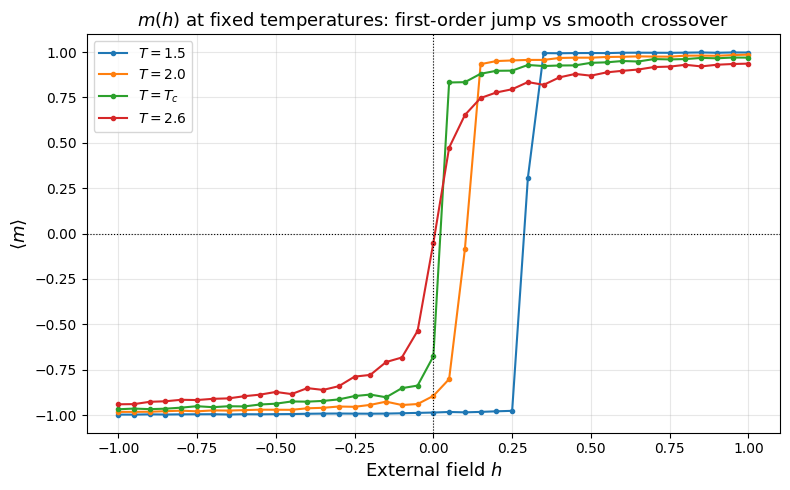

In [3]:
H_VALUES    = np.linspace(-1.0, 1.0, 41)
T_FIXED     = [1.5, 2.0, TC, 2.6]
EQUIL_H     = 80_000
N_SAMP_H    = 100
SAMP_INT_H  = 400

results_h = {}   # results_h[T] = array of <m> vs h

for T in T_FIXED:
    label = f"T = {T:.4f}" if abs(T - TC) < 0.001 else f"T = {T:.1f}"
    print(f"{label} ...", end=' ', flush=True)
    beta    = 1.0 / T
    # Start from spin-down, sweep h upward
    lattice = -np.ones((L, L), dtype=int)
    mags    = []
    for h in H_VALUES:
        metropolis(lattice, L, beta, J, h, EQUIL_H)
        m_samples = []
        for _ in range(N_SAMP_H):
            metropolis(lattice, L, beta, J, h, SAMP_INT_H)
            m_samples.append(np.mean(lattice))
        mags.append(np.mean(m_samples))
    results_h[T] = np.array(mags)
    print("done")

fig, ax = plt.subplots(figsize=(8, 5))
for T in T_FIXED:
    lbl = f"$T = T_c$" if abs(T - TC) < 0.001 else f"$T = {T:.1f}$"
    ax.plot(H_VALUES, results_h[T], 'o-', ms=3, lw=1.5, label=lbl)
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.axvline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel("External field $h$", fontsize=13)
ax.set_ylabel(r"$\langle m \rangle$", fontsize=13)
ax.set_title("$m(h)$ at fixed temperatures: first-order jump vs smooth crossover",
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.4  Hysteresis

A defining feature of first-order transitions is **hysteresis**: the system does not jump at $h = 0$ instantaneously. When $h$ is swept slowly from negative to positive, the system stays in the metastable spin-down phase past $h = 0$ and only flips when a nucleation event kicks it over the free-energy barrier. The reverse sweep traces a different path.

To observe this we sweep $h$ forward and backward **without re-equilibrating** at each step — the lattice state is carried continuously through the sweep. The area enclosed by the forward and backward curves is the energy dissipated per cycle.

The loop narrows as $T \to T_c$ and closes entirely at $T_c$, where the barrier height goes to zero and the transition becomes continuous.

T = 1.5 ... done
T = 2.0 ... done
T = 2.2 ... done


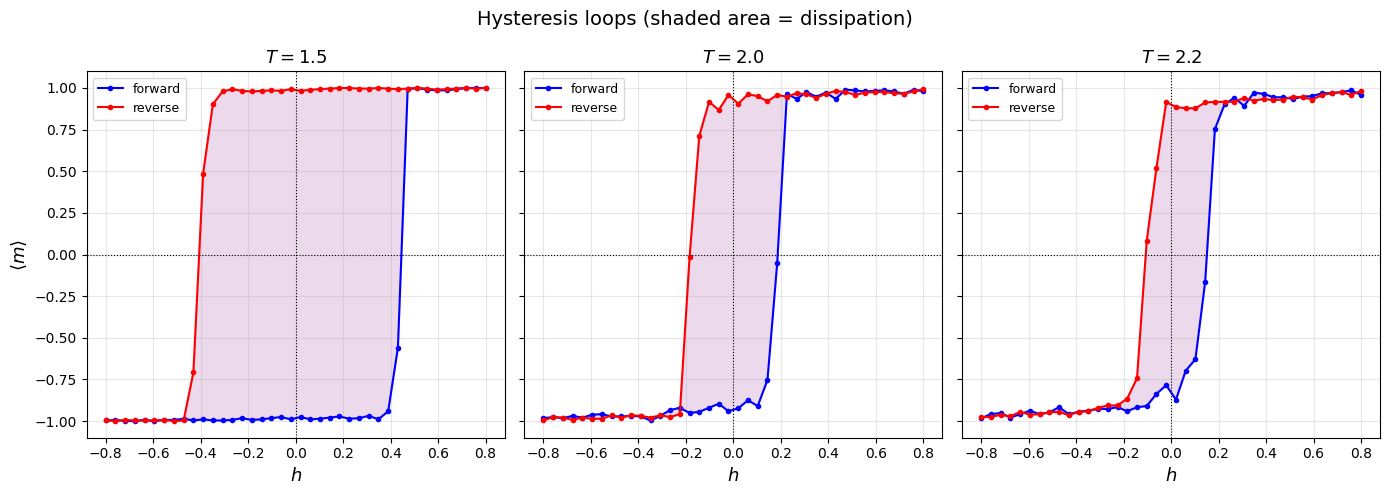

In [4]:
def hysteresis_loop(T, h_max, n_h, L, init_steps, sweep_steps, J=1.0):
    """
    Sweep h from -h_max to +h_max (forward) then back (reverse).
    The lattice state is carried continuously — no re-equilibration between steps.
    Returns (h_values, m_forward, m_reverse).
    """
    beta     = 1.0 / T
    h_values = np.linspace(-h_max, h_max, n_h)

    # Start equilibrated at h = -h_max
    lattice = -np.ones((L, L), dtype=int)
    metropolis(lattice, L, beta, J, -h_max, init_steps)

    # Forward sweep
    m_fwd = []
    for h in h_values:
        metropolis(lattice, L, beta, J, h, sweep_steps)
        m_fwd.append(np.mean(lattice))

    # Reverse sweep (continue from end of forward)
    m_rev = []
    for h in reversed(h_values):
        metropolis(lattice, L, beta, J, h, sweep_steps)
        m_rev.append(np.mean(lattice))
    m_rev = list(reversed(m_rev))

    return h_values, np.array(m_fwd), np.array(m_rev)


H_MAX       = 0.8
N_H         = 40
INIT_STEPS  = 60_000
SWEEP_STEPS = 20_000   # steps per h value — fewer than equilibrium, deliberate
T_HYST      = [1.5, 2.0, 2.2]

fig, axes = plt.subplots(1, len(T_HYST), figsize=(14, 5), sharey=True)

for ax, T in zip(axes, T_HYST):
    print(f"T = {T} ...", end=' ', flush=True)
    h_vals, m_fwd, m_rev = hysteresis_loop(T, H_MAX, N_H, L,
                                            INIT_STEPS, SWEEP_STEPS)
    ax.plot(h_vals, m_fwd, 'b-o', ms=3, lw=1.5, label="forward")
    ax.plot(h_vals, m_rev, 'r-o', ms=3, lw=1.5, label="reverse")
    ax.fill_between(h_vals, m_fwd, m_rev, alpha=0.15, color='purple')
    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.axvline(0, color='k', lw=0.8, ls=':')
    ax.set_xlabel("$h$", fontsize=13)
    ax.set_title(f"$T = {T}$", fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    print("done")

axes[0].set_ylabel(r"$\langle m \rangle$", fontsize=13)
plt.suptitle("Hysteresis loops (shaded area = dissipation)", fontsize=14)
plt.tight_layout()
plt.show()

## 4.5  The Jump Shrinks to Zero at $T_c$

The size of the discontinuity in $m(h=0^+) - m(h=0^-)$ is the **order parameter jump** of the first-order transition. It equals $2m_0(T)$, where $m_0(T)$ is the spontaneous magnetization at $h = 0$.

As $T \to T_c^-$, $m_0(T) \to 0$ continuously (as $(T_c - T)^\beta$ with $\beta = 1/8$), so the jump vanishes at $T_c$. The first-order transition becomes second-order at the critical endpoint.

We measure the jump size by taking the difference between $m$ just above and just below $h = 0$ at several temperatures.

T = 1.2000:  jump = 1.994
T = 1.5000:  jump = 1.973
T = 1.8000:  jump = 1.924
T = 2.0000:  jump = 1.832
T = 2.1000:  jump = 1.766
T = 2.2000:  jump = 1.699
T = 2.2692:  jump = 1.575


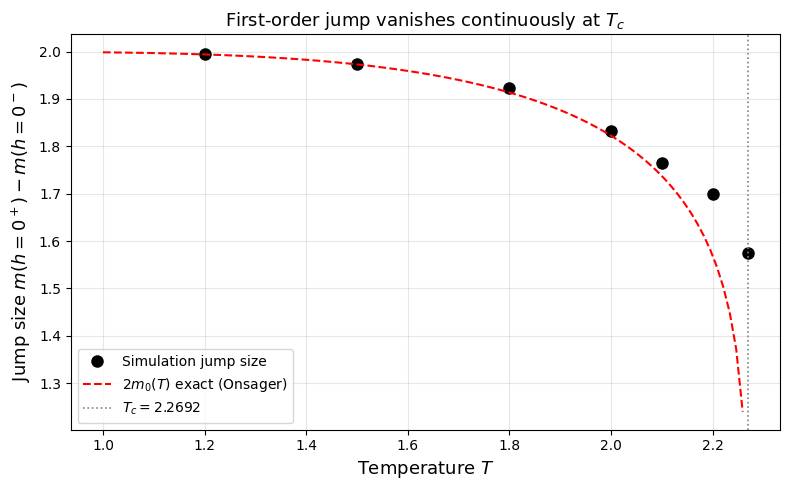

In [5]:
T_JUMP   = np.array([1.2, 1.5, 1.8, 2.0, 2.1, 2.2, TC])
H_SMALL  = 0.02    # small positive field to pick one branch
EQUIL_J  = 100_000
N_SAMP_J = 200
SAMP_J   = 300

jump_sizes = []

for T in T_JUMP:
    beta = 1.0 / T
    m_vals = []
    for sign in (+1, -1):   # measure m at h = +H_SMALL and h = -H_SMALL
        h       = sign * H_SMALL
        lattice = sign * np.ones((L, L), dtype=int)   # start aligned with field
        metropolis(lattice, L, beta, J, h, EQUIL_J)
        samples = []
        for _ in range(N_SAMP_J):
            metropolis(lattice, L, beta, J, h, SAMP_J)
            samples.append(np.mean(lattice))
        m_vals.append(np.mean(samples))
    jump = m_vals[0] - m_vals[1]   # m(+h) - m(-h)
    jump_sizes.append(jump)
    print(f"T = {T:.4f}:  jump = {jump:.3f}")

# Theoretical curve: 2 * m_0(T) from Onsager (mean-field exponent for visual guide)
T_theory = np.linspace(1.0, TC - 0.01, 100)
m0_theory = (1 - (np.sinh(2 / T_theory))**(-4)) ** (1/8)   # exact Onsager result

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T_JUMP, jump_sizes, 'ko', ms=8, label="Simulation jump size")
ax.plot(T_theory, 2 * m0_theory, 'r--', lw=1.5,
        label="$2m_0(T)$ exact (Onsager)")
ax.axvline(TC, color='grey', ls=':', lw=1.2, label=f"$T_c = {TC:.4f}$")
ax.set_xlabel("Temperature $T$", fontsize=13)
ax.set_ylabel("Jump size $m(h{=}0^+) - m(h{=}0^-)$", fontsize=13)
ax.set_title("First-order jump vanishes continuously at $T_c$", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.6  Landau Free Energy Landscape

Landau theory organises all of this into a single picture. Near the transition, we expand the free energy density in powers of the order parameter $m$:

$$F(m) = a(T)\, m^2 + b\, m^4 - h m$$

with $b > 0$ and $a(T) = a_0(T - T_c)$ changing sign at $T_c$. The equilibrium state minimises $F$.

- **$T > T_c$, $h = 0$:** single minimum at $m = 0$ — paramagnetic.
- **$T < T_c$, $h = 0$:** two equal minima at $m = \pm m_0$ — ferromagnetic, two phases coexist.
- **$T < T_c$, $h \neq 0$:** the field tilts the landscape, making one minimum deeper. As $h$ crosses zero the deeper minimum switches sides — this is the first-order transition.

The barrier between the two minima is what causes hysteresis: the system stays trapped in the shallower minimum until fluctuations carry it over.

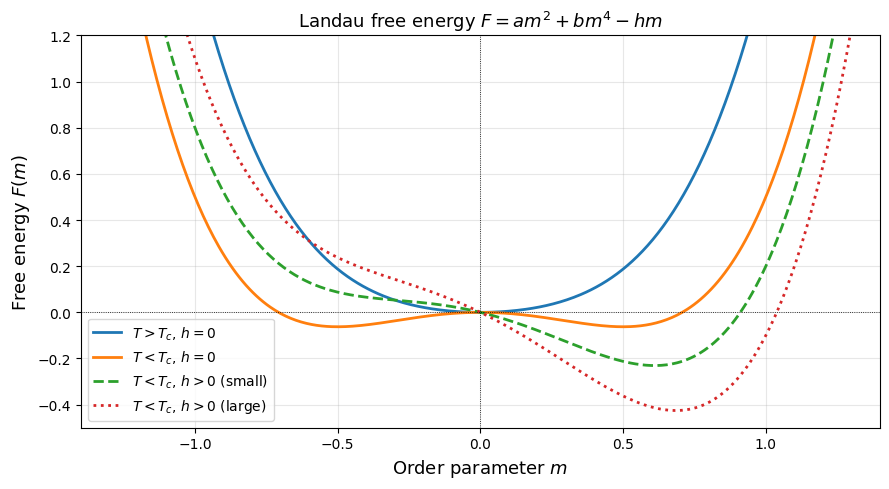

In [6]:
m_vals = np.linspace(-1.5, 1.5, 500)
b      = 1.0   # fixed

scenarios = [
    # (a,    h,    label,             linestyle)
    ( 0.5,   0.0,  r"$T > T_c$, $h=0$",           'C0-'),
    (-0.5,   0.0,  r"$T < T_c$, $h=0$",           'C1-'),
    (-0.5,   0.3,  r"$T < T_c$, $h>0$ (small)",   'C2--'),
    (-0.5,   0.6,  r"$T < T_c$, $h>0$ (large)",   'C3:'),
]

fig, ax = plt.subplots(figsize=(9, 5))
for a, h, label, ls in scenarios:
    F = a * m_vals**2 + b * m_vals**4 - h * m_vals
    ax.plot(m_vals, F, ls, lw=2, label=label)

ax.axhline(0, color='k', lw=0.6, ls=':')
ax.axvline(0, color='k', lw=0.6, ls=':')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-0.5, 1.2)
ax.set_xlabel("Order parameter $m$", fontsize=13)
ax.set_ylabel("Free energy $F(m)$", fontsize=13)
ax.set_title(r"Landau free energy $F = am^2 + bm^4 - hm$", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.7  Connecting to Quantum Phase Transitions

The ideas developed in this notebook are not limited to classical systems. First-order and continuous transitions both occur in quantum phase diagrams, and the tools for identifying them are the same.

**First-order quantum transitions** occur when the ground state changes discontinuously as a coupling constant is varied. There is no quantum critical point, no diverging correlation length, and no universal scaling. Instead, the two ground states coexist at the transition, just as the two magnetic phases coexist at $h = 0$ here. Identifying a first-order quantum transition requires looking for hysteresis-like sensitivity to initial conditions, a jump in the order parameter, or a level crossing (rather than avoided crossing) in the energy spectrum.

**Continuous quantum transitions** are the quantum analogue of the second-order transition at $(T_c, h = 0)$. They occur at $T = 0$ as a function of a Hamiltonian parameter, and they are characterised by a gap that closes, a correlation length that diverges, and universal critical exponents — exactly as we saw in notebooks 01–02 for the classical Ising model.

**Fluctuation-induced first-order transitions** are a subtler phenomenon: a transition that appears continuous at mean-field level is rendered first-order by fluctuations. This happens in some quantum phase diagrams and makes careful numerical diagnosis essential — an apparently smooth order parameter may conceal a weak discontinuity at the true transition.

The Landau free energy picture also carries over. Near a quantum critical point the effective free energy (now a functional of the ground state wavefunction) has the same polynomial structure $F \sim a\phi^2 + b\phi^4 + \ldots$, and the sign of $b$ again determines whether the transition is continuous or first-order. In notebook 06 we meet the simplest quantum model with a continuous phase transition: the 1D transverse-field Ising model.

## Exercises

1. **Phase coexistence snapshots.** At $T = 1.8$ and $h = 0$, run a long simulation and take lattice snapshots every 10 000 steps. You should occasionally see domain walls between spin-up and spin-down regions. How does the domain structure change as you approach $T_c$?

2. **Hysteresis loop area.** The area enclosed by the forward and reverse curves in section 4.4 is the energy dissipated per field cycle. Compute it numerically (using `np.trapz`) for several temperatures. How does the loop area scale with $T_c - T$?

3. **System-size dependence of the jump.** Repeat the $m(h)$ sweep from section 4.3 at $T = 1.8$ for $L = 16, 24, 32, 48$. The apparent jump width narrows as $L$ increases. Fit the width vs $L$ and extrapolate to $L \to \infty$ to estimate the true discontinuity.

4. **Landau minimum.** For the Landau free energy in section 4.6, find the minimum analytically by differentiating $F$ with respect to $m$ and solving $\partial F / \partial m = 0$ numerically (e.g. with `scipy.optimize.brentq`). Plot the equilibrium $m^*(h)$ as a function of $h$ for $a = -0.5$ and compare with the simulation result from section 4.3.